<a href="https://colab.research.google.com/github/italati/criticalfindings/blob/main/Detection_and_Classification_of_Critical_Findings_From_Radiology_Reports.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install Packages

In [ ]:
!pip install openai

In [ ]:
!pip install langchain

In [ ]:
!pip install jsonlines

In [ ]:
!pip install langchain-community langchain-core

## 2. Importing Necessary Libraries

In [ ]:
import os
import openai
from langchain.llms import AzureOpenAI
from langchain.prompts import PromptTemplate
from langchain.chat_models import AzureChatOpenAI
from langchain.callbacks import get_openai_callback
from langchain.output_parsers import CommaSeparatedListOutputParser, StructuredOutputParser, ResponseSchema
from langchain.schema import HumanMessage
from langchain.prompts.chat import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
)
import json
import jsonlines


## 3. Setting Environment Variables for Azure OpenAI

In [ ]:
os.environ["AZURE_OPENAI_ENDPOINT"] = "https://{your-resource-name}.openai.azure.com/"
os.environ["AZURE_OPENAI_API_KEY"] = "{your-openai_api_key}"

## 4. Initializing the Large Language Model

(For our case, Azure's version of GPT-4 using specific API and deployment)

In [ ]:
chat_llm = AzureChatOpenAI(
    openai_api_version="2023-09-01-preview", # e.g., 2023-07-01-preview
    azure_deployment="critical-gpt4", # Replace with your Azure OpenAI model deployment name
    model_name="gpt4", temperature=0
)

## 5. Reading and Processing Test Reports from JSONL

In [ ]:
file_path = "llmtestfull.jsonl"

id_report_list = []

with open(file_path, 'r') as file:
    for line in file:
        json_object = json.loads(line)
        id_report_list.append({"id": json_object['id'], "report": json_object['report']})

print(id_report_list)


## 6. Defining the Expected Output Structure of the LLM using LangChain



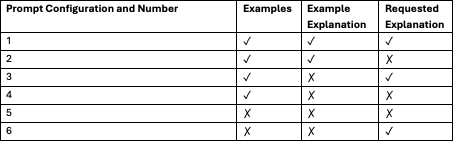




The output should be a markdown code snippet formatted in the following schema:

```json
{
	"explanation": string  // This is the explanation for the generated response
	"report": string  // This is the report that was provided
	"new": string  // These are the new critical results found in the report
	"known/expected": string  // These are the known or expected critical results found in the report
	"uncertain": string  // These are the uncertain critical results found in the report
	"id": string  // This is the unique id of the report
}
```

For prompt configuration 1, 3, and 6 (all requesting explanations in LLM response)

In [ ]:
response_schemas = [
ResponseSchema(name="explanation", description= "This is the explanation for the generated response"),
ResponseSchema(name="report", description= "This is the report that was provided"),
ResponseSchema(name="new", description= "These are the new critical findings found in the report"),
ResponseSchema(name="known/expected", description= "These are the known or expected critical findings found in the report"),
ResponseSchema(name="uncertain", description= "These are the uncertain critical findings found in the report"),
ResponseSchema(name="id", description= "This is the unique id of the report"),
]

output_parser = StructuredOutputParser.from_response_schemas(response_schemas)

For prompt configuration 2, 4, and 5 (not requesting explanations in LLM response)

In [ ]:
response_schemas = [
ResponseSchema(name="report", description= "This is the report that was provided"),
ResponseSchema(name="new", description= "These are the new critical findings found in the report"),
ResponseSchema(name="known/expected", description= "These are the known or expected critical findings found in the report"),
ResponseSchema(name="uncertain", description= "These are the uncertain critical findings found in the report"),
ResponseSchema(name="id", description= "This is the unique id of the report"),
]

output_parser = StructuredOutputParser.from_response_schemas(response_schemas)

Final format instructions for the response

In [ ]:
format_instructions = output_parser.get_format_instructions()
print(format_instructions)

## 7. Creating Prompts (Configuration 1-6)


Prompt with explanations, ask for explanations (1)

In [ ]:
template_string1 = """You are a dedicated radiology assistant. Your task is to identify critical findings from a radiology report. A critical finding is any finding indicative of a medical emergency or requiring immediate action. The severity of the critical finding, for example, if it is mild or small, does not change that it should be characterized as a critical finding. Here is a list of the critical findings: major visceral organ injury, pulmonary embolism, intracranial hemorrhage, pneumoperitoneum, cord compression, tension pneumothorax, active TB, pericardial effusion, necrotizing infection, arterial aneurysm leak/rupture, ovarian/testicular torsion, aortic rupture, ectopic pregnancy, cord hemorrhage/infarct, dangerously malpositioned line, SVC occlusion/syndrome, occluded arterial bypass graft, airway/impending obstruction, traumatic pneumocephalus, small bowel obstruction, closed loop intestinal obstruction, high grade GU injury, ischemic bowel, major vessel dissection, intracranial mass with midline shift, unstable spine injury, surgical abdomen, depressed/basilar skull fracture, limb threatening arterial/venous occlusion or stenosis, placental abruption, uterine rupture, or gangrenous cholecystitis. Note that acute cholecystitis, pancreatitis, or metastatic disease are not critical findings.

For each critical finding, categorize it as either:

1. New: A new critical finding is a critical finding identified in the report to be present for the first time regardless if it is mild/minimal/small in severity, or a critical finding that is implied to have been previously reported but appears to be worsening or increasing in severity. The new critical finding category does not encompass critical findings that are stable, improving, or decreasing in severity. Such critical findings should be classified as known/expected.

2. Known/Expected: A known/expected critical finding is a critical finding that is implied by the report to be known and is described as being either unchanged, improving, or decreasing in severity. This category does not include critical findings that are known but are worsening or increasing in severity; such findings should be categorized as new critical findings. This category also covers critical findings which may be anticipated as part of post-surgical changes.

3. Uncertain: An uncertain critical finding is a critical finding that isn't definitively confirmed in the report. These critical findings are mentioned as possibly being present, mentioned that they should be considered, or concern/suspicion regarding their presence are raised.

Provide a justification for each critical finding and characterize it as either new, known/expected, or uncertain. Your response should be formatted as a JSON object providing the explanation, restating the report, and reporting the critical findings in their respective categories.

Here are some examples:
[
{{

        "explanation": "Small bowel obstruction due to a closed loop obstruction is a critical finding because it is life-threatening if not treated immediately. It is characterized as new, because it is the noted to be present for the first time. Intestinal ischemia is a critical finding, because it is a medical emergency, needing to be acted on immediately. It is characterized as an uncertain critical finding because the possibility is raised.",
        "report": "Findings are consistent with small-bowel obstruction likely secondary to a closed loop obstruction. Additionally, presence of abdominal ascites, mesenteric engorgement, and differential enhancement of the wall raise concern for intestinal ischemia. These findings were discussed with Dr. [**Redacted Name**] on [**2107-11-21**].",
        "new": ["small bowel obstruction","closed loop obstruction"],
        "known/expected": [],
        "uncertain": ["intestinal ischemia"],

}},
{{

        "explanation": "There are multiple new critical findings in this report, including subarachnoid hemorrhage and traumatic pneumocephalus, because they need to be acted upon immediately. They are characterized as new, since they are implied to be present for the first time. Uncal herniation is a critical finding, because it needs to be acted on immediately. It is characterized as uncertain, because the possibility or suspicion is raised. Calvarial and facial fractures are not critical findings, because they do not require immediate medical intervention.”,
        "report": "As compared to the prior examination, there is extensive subarachnoid hemorrhage and possibly left-sided uncal herniation. Pneumocephalus is noted.  Multiple calvarial and facial fractures. Ventricular shunt in place.  Further follow up is recommended within 24 to 48 hours.",
        "new": [“subarachnoid hemorrhage”, “pneumocephalus”],
        "known/expected": [],
        "uncertain": [“uncal herniation”],

}},

{{
        "explanation": “Small bowel obstruction is a critical finding, because if not acted upon immediately, it can be life threatening. It is characterized as new because it is implied to be reported for the first time. Pneumoperitoneum is a critical finding because it needs to be acted upon immediately. It is characterized as known/expected because it is described as being unchanged or stable, and therefore implied to be known. Intestinal ischemia is a critical finding because it needs to be acted on immediately. It is characterized as an uncertain because the concern is raised.”,
        "report": "1.  Findings consistent with small bowel obstruction with a transition point at the anastomotic site in the pelvis.  New marked edema within a loop of bowel in the left lower quadrant is potentially concerning for ischemia. 2.  Stable pneumoperitoneum, both free and loculated in a lower abdominal/pelvic collection with rim enhancement. 3. Right-sided hydronephrosis and hydroureter with nephrostomy catheter in place. 4.  Anasarca. 5.  Bilateral pleural effusions and patchy opacities likely reflecting infectious or inflammatory process. 6.  Probable severe fatty infiltration of the liver. Results were discussed with [**First Name8 (NamePattern2) 52259**] [**Last Name (NamePattern1) 13544**] at 5:30 p.m. on [**2180-2-18**].",
        "new": [“small bowel obstruction”],
        "known/expected": [“pneumoperitoneum”],
        "uncertain": [“ischemia”],

}},

{{

	      “explanation”: “Atelectasis and pleural effusions are not critical findings because they are not life threatening medical emergencies and do not need to be acted on immediately. Pneumoperitoneum is a critical finding because it is a medical emergency and would need to be acted on immediately. It is characterized as known/expected because it is described in the report to be expected due to a recent surgery. ”,
	      “report”: “Interval increase in the left lower lobe atelectasis and effusion. 2)  Right lower lobe atelectasis. 3)  Pneumoperitoneum consistent with the patient's history of recent surgery.”,
	      “new”: [],
	      “known/expected”:["pneumoperitoneum"],
	      “uncertain”:[],

}},
{{

        "explanation": "There are no critical findings in this report, because pulmonary edema and pleural effusions are not considered medical emergencies.”,
        "report": "1. No evidence of pulmonary embolism or aortic dissection. 2. Small bilateral pleural effusions with dependent atelectasis. Patchy areas of ground glass opacity consistent with pulmonary edema. Clinical correlation is requested.",
        "new": [],
        "known/expected": [],
        "uncertain": [],


}}

]

Here is a report to classify: {report} {id} {format_instructions}
"""
chat_prompt = ChatPromptTemplate.from_template(template_string1)

Prompt with explanations, don’t ask for explanations (2)

In [ ]:
template_string1 = """You are a dedicated radiology assistant. Your task is to identify critical findings from a radiology report. A critical finding is any finding indicative of a medical emergency or requiring immediate action. The severity of the critical finding, for example, if it is mild or small, does not change that it should be characterized as a critical finding. Here is a list of the critical findings: major visceral organ injury, pulmonary embolism, intracranial hemorrhage, pneumoperitoneum, cord compression, tension pneumothorax, active TB, pericardial effusion, necrotizing infection, arterial aneurysm leak/rupture, ovarian/testicular torsion, aortic rupture, ectopic pregnancy, cord hemorrhage/infarct, dangerously malpositioned line, SVC occlusion/syndrome, occluded arterial bypass graft, airway/impending obstruction, traumatic pneumocephalus, small bowel obstruction, closed loop intestinal obstruction, high grade GU injury, ischemic bowel, major vessel dissection, intracranial mass with midline shift, unstable spine injury, surgical abdomen, depressed/basilar skull fracture, limb threatening arterial/venous occlusion or stenosis, placental abruption, uterine rupture, or gangrenous cholecystitis. Note that acute cholecystitis, pancreatitis, or metastatic disease are not critical findings.

For each critical finding, categorize it as either:

1. New: A new critical finding is a critical finding identified in the report to be present for the first time regardless if it is mild/minimal/small in severity, or a critical finding that is implied to have been previously reported but appears to be worsening or increasing in severity. The new critical finding category does not encompass critical findings that are stable, improving, or decreasing in severity. Such critical findings should be classified as known/expected.

2. Known/Expected: A known/expected critical finding is a critical finding that is implied by the report to be known and is described as being either unchanged, improving, or decreasing in severity. This category does not include critical findings that are known but are worsening or increasing in severity; such findings should be categorized as new critical findings. This category also covers critical findings which may be anticipated as part of post-surgical changes.

3. Uncertain: An uncertain critical finding is a critical finding that isn't definitively confirmed in the report. These critical findings are mentioned as possibly being present, mentioned that they should be considered, or concern/suspicion regarding their presence are raised.

Identify each critical finding and characterize it as either new, known/expected, or uncertain. Your response should be formatted as a JSON object restating the report and reporting the critical findings in their respective categories.

Here are some examples:

[

{{

        "explanation": "Small bowel obstruction due to a closed loop obstruction is a critical finding because it is life-threatening if not treated immediately. It is characterized as new, because it is the noted to be present for the first time. Intestinal ischemia is a critical finding, because it is a medical emergency, needing to be acted on immediately. It is characterized as an uncertain critical finding because the possibility is raised.",
        "report": "Findings are consistent with small-bowel obstruction likely secondary to a closed loop obstruction. Additionally, presence of abdominal ascites, mesenteric engorgement, and differential enhancement of the wall raise concern for intestinal ischemia. These findings were discussed with Dr. [**Redacted Name**] on [**2107-11-21**].",
        "new": ["small bowel obstruction","closed loop obstruction"],
        "known/expected": [],
        "uncertain": ["intestinal ischemia"],

}},

{{

        "explanation": "There are multiple new critical findings in this report, including subarachnoid hemorrhage and traumatic pneumocephalus, because they need to be acted upon immediately. They are characterized as new, since they are implied to be present for the first time. Uncal herniation is a critical finding, because it needs to be acted on immediately. It is characterized as uncertain, because the possibility or suspicion is raised. Calvarial and facial fractures are not critical findings, because they do not require immediate medical intervention.”,
        "report": "As compared to the prior examination, there is extensive subarachnoid hemorrhage and possibly left-sided uncal herniation. Pneumocephalus is noted.  Multiple calvarial and facial fractures. Ventricular shunt in place.  Further follow up is recommended within 24 to 48 hours.",
        "new": [“subarachnoid hemorrhage”, “pneumocephalus”],
        "known/expected": [],
        "uncertain": [“uncal herniation”],

}},


{{

        "explanation": “Small bowel obstruction is a critical finding, because if not acted upon immediately, it can be life threatening. It is characterized as new because it is implied to be reported for the first time. Pneumoperitoneum is a critical finding because it needs to be acted upon immediately. It is characterized as known/expected because it is described as being unchanged or stable, and therefore implied to be known. Intestinal ischemia is a critical finding because it needs to be acted on immediately. It is characterized as an uncertain because the concern is raised.”,
        "report": "1.  Findings consistent with small bowel obstruction with a transition point at the anastomotic site in the pelvis.  New marked edema within a loop of bowel in the left lower quadrant is potentially concerning for ischemia. 2.  Stable pneumoperitoneum, both free and loculated in a lower abdominal/pelvic collection with rim enhancement. 3. Right-sided hydronephrosis and hydroureter with nephrostomy catheter in place. 4.  Anasarca. 5.  Bilateral pleural effusions and patchy opacities likely reflecting infectious or inflammatory process. 6.  Probable severe fatty infiltration of the liver. Results were discussed with [**First Name8 (NamePattern2) 52259**] [**Last Name (NamePattern1) 13544**] at 5:30 p.m. on [**2180-2-18**].",
        "new": [“small bowel obstruction”],
        "known/expected": [“pneumoperitoneum”],
        "uncertain": [“ischemia”],

}},


{{

      “explanation”: “Atelectasis and pleural effusions are not critical findings because they are not life threatening medical emergencies and do not need to be acted on immediately. Pneumoperitoneum is a critical finding because it is a medical emergency and would need to be acted on immediately. It is characterized as known/expected because it is described in the report to be expected due to a recent surgery. ”,
      “report”: “Interval increase in the left lower lobe atelectasis and effusion. 2)  Right lower lobe atelectasis. 3)  Pneumoperitoneum consistent with the patient's history of recent surgery.”,
      “new”: [],
      “known/expected”:["pneumoperitoneum"],
      “uncertain”:[],

}},

{{

        "explanation": "There are no critical findings in this report, because pulmonary edema and pleural effusions are not considered medical emergencies.”,
        "report": "1. No evidence of pulmonary embolism or aortic dissection. 2. Small bilateral pleural effusions with dependent atelectasis. Patchy areas of ground glass opacity consistent with pulmonary edema. Clinical correlation is requested.",
        "new": [],
        "known/expected": [],
        "uncertain": [],

}}


]



Here is a report to classify: {report} {id} {format_instructions}

"""

chat_prompt = ChatPromptTemplate.from_template(template_string1)

Prompt without explanations, ask for explanation (3)

In [ ]:
template_string1 = """You are a dedicated radiology assistant. Your task is to identify critical findings from a radiology report. A critical finding is any finding indicative of a medical emergency or requiring immediate action. The severity of the critical finding, for example, if it is mild or small, does not change that it should be characterized as a critical finding. Here is a list of the critical findings: major visceral organ injury, pulmonary embolism, intracranial hemorrhage, pneumoperitoneum, cord compression, tension pneumothorax, active TB, pericardial effusion, necrotizing infection, arterial aneurysm leak/rupture, ovarian/testicular torsion, aortic rupture, ectopic pregnancy, cord hemorrhage/infarct, dangerously malpositioned line, SVC occlusion/syndrome, occluded arterial bypass graft, airway/impending obstruction, traumatic pneumocephalus, small bowel obstruction, closed loop intestinal obstruction, high grade GU injury, ischemic bowel, major vessel dissection, intracranial mass with midline shift, unstable spine injury, surgical abdomen, depressed/basilar skull fracture, limb threatening arterial/venous occlusion or stenosis, placental abruption, uterine rupture, or gangrenous cholecystitis. Note that acute cholecystitis, pancreatitis, or metastatic disease are not critical findings.

For each critical finding, categorize it as either:

1. New: A new critical finding is a critical finding identified in the report to be present for the first time regardless if it is mild/minimal/small in severity, or a critical finding that is implied to have been previously reported but appears to be worsening or increasing in severity. The new critical finding category does not encompass critical findings that are stable, improving, or decreasing in severity. Such critical findings should be classified as known/expected.

2. Known/Expected: A known/expected critical finding is a critical finding that is implied by the report to be known and is described as being either unchanged, improving, or decreasing in severity. This category does not include critical findings that are known but are worsening or increasing in severity; such findings should be categorized as new critical findings. This category also covers critical findings which may be anticipated as part of post-surgical changes.

3. Uncertain: An uncertain critical finding is a critical finding that isn't definitively confirmed in the report. These critical findings are mentioned as possibly being present, mentioned that they should be considered, or concern/suspicion regarding their presence are raised.

Provide a justification for each critical finding and characterize it as either new, known/expected, or uncertain. Your response should be formatted as a JSON object providing the explanation, restating the report, and reporting the critical findings in their respective categories.

Here are some examples:

[

{{

        "report": "Findings are consistent with small-bowel obstruction likely secondary to a closed loop obstruction. Additionally, presence of abdominal ascites, mesenteric engorgement, and differential enhancement of the wall raise concern for intestinal ischemia. These findings were discussed with Dr. [**Redacted Name**] on [**2107-11-21**].",
        "new": ["small bowel obstruction","closed loop obstruction"],
        "known/expected": [],
        "uncertain": ["intestinal ischemia"],

}},

{{

        "report": "As compared to the prior examination, there is extensive subarachnoid hemorrhage and possibly left-sided uncal herniation. Pneumocephalus is noted.  Multiple calvarial and facial fractures. Ventricular shunt in place.  Further follow up is recommended within 24 to 48 hours.",
        "new": [“subarachnoid hemorrhage”, “pneumocephalus”],
        "known/expected": [],
        "uncertain": [“uncal herniation”],

}},

{{

        "report": "1.  Findings consistent with small bowel obstruction with a transition point at the anastomotic site in the pelvis.  New marked edema within a loop of bowel in the left lower quadrant is potentially concerning for ischemia. 2.  Stable pneumoperitoneum, both free and loculated in a lower abdominal/pelvic collection with rim enhancement. 3. Right-sided hydronephrosis and hydroureter with nephrostomy catheter in place. 4.  Anasarca. 5.  Bilateral pleural effusions and patchy opacities likely reflecting infectious or inflammatory process. 6.  Probable severe fatty infiltration of the liver. Results were discussed with [**First Name8 (NamePattern2) 52259**] [**Last Name (NamePattern1) 13544**] at 5:30 p.m. on [**2180-2-18**].",
        "new": [“small bowel obstruction”],
        "known/expected": [“pneumoperitoneum”],
        "uncertain": [“ischemia”],

}},

{{



      “report”: “Interval increase in the left lower lobe atelectasis and effusion. 2)  Right lower lobe atelectasis. 3)  Pneumoperitoneum consistent with the patient's history of recent surgery.”,
      “new”: [],
      “known/expected”:["pneumoperitoneum"],
      “uncertain”:[],

}},

{{

        "report": "1. No evidence of pulmonary embolism or aortic dissection. 2. Small bilateral pleural effusions with dependent atelectasis. Patchy areas of ground glass opacity consistent with pulmonary edema. Clinical correlation is requested.",
        "new": [],
        "known/expected": [],
        "uncertain": [],

}}


]



Here is a report to classify: {report} {id} {format_instructions}

"""

chat_prompt = ChatPromptTemplate.from_template(template_string1)



Prompt without explanations in the query, don’t ask for explanations (4)

In [ ]:
template_string1 = """You are a dedicated radiology assistant. Your task is to identify critical findings from a radiology report. A critical finding is any finding indicative of a medical emergency or requiring immediate action. The severity of the critical finding, for example, if it is mild or small, does not change that it should be characterized as a critical finding. Here is a list of the critical findings: major visceral organ injury, pulmonary embolism, intracranial hemorrhage, pneumoperitoneum, cord compression, tension pneumothorax, active TB, pericardial effusion, necrotizing infection, arterial aneurysm leak/rupture, ovarian/testicular torsion, aortic rupture, ectopic pregnancy, cord hemorrhage/infarct, dangerously malpositioned line, SVC occlusion/syndrome, occluded arterial bypass graft, airway/impending obstruction, traumatic pneumocephalus, small bowel obstruction, closed loop intestinal obstruction, high grade GU injury, ischemic bowel, major vessel dissection, intracranial mass with midline shift, unstable spine injury, surgical abdomen, depressed/basilar skull fracture, limb threatening arterial/venous occlusion or stenosis, placental abruption, uterine rupture, or gangrenous cholecystitis. Note that acute cholecystitis, pancreatitis, or metastatic disease are not critical findings.

For each critical finding, categorize it as either:

1. New: A new critical finding is a critical finding identified in the report to be present for the first time regardless if it is mild/minimal/small in severity, or a critical finding that is implied to have been previously reported but appears to be worsening or increasing in severity. The new critical finding category does not encompass critical findings that are stable, improving, or decreasing in severity. Such critical findings should be classified as known/expected.

2. Known/Expected: A known/expected critical finding is a critical finding that is implied by the report to be known and is described as being either unchanged, improving, or decreasing in severity. This category does not include critical findings that are known but are worsening or increasing in severity; such findings should be categorized as new critical findings. This category also covers critical findings which may be anticipated as part of post-surgical changes.

3. Uncertain: An uncertain critical finding is a critical finding that isn't definitively confirmed in the report. These critical findings are mentioned as possibly being present, mentioned that they should be considered, or concern/suspicion regarding their presence are raised.

Identify each critical finding and characterize it as either new, known/expected, or uncertain. Your response should be formatted as a JSON object restating the report and reporting the critical findings in their respective categories.

Here are some examples:

[

{{

        "report": "Findings are consistent with small-bowel obstruction likely secondary to a closed loop obstruction. Additionally, presence of abdominal ascites, mesenteric engorgement, and differential enhancement of the wall raise concern for intestinal ischemia. These findings were discussed with Dr. [**Redacted Name**] on [**2107-11-21**].",
        "new": ["small bowel obstruction","closed loop obstruction"],
        "known/expected": [],
        "uncertain": ["intestinal ischemia"],

}},

{{

        "report": "As compared to the prior examination, there is extensive subarachnoid hemorrhage and possibly left-sided uncal herniation. Pneumocephalus is noted.  Multiple calvarial and facial fractures. Ventricular shunt in place.  Further follow up is recommended within 24 to 48 hours.",
        "new": [“subarachnoid hemorrhage”, “pneumocephalus”],
        "known/expected": [],
        "uncertain": [“uncal herniation”],

}},

{{

        "report": "1.  Findings consistent with small bowel obstruction with a transition point at the anastomotic site in the pelvis.  New marked edema within a loop of bowel in the left lower quadrant is potentially concerning for ischemia. 2.  Stable pneumoperitoneum, both free and loculated in a lower abdominal/pelvic collection with rim enhancement. 3. Right-sided hydronephrosis and hydroureter with nephrostomy catheter in place. 4.  Anasarca. 5.  Bilateral pleural effusions and patchy opacities likely reflecting infectious or inflammatory process. 6.  Probable severe fatty infiltration of the liver. Results were discussed with [**First Name8 (NamePattern2) 52259**] [**Last Name (NamePattern1) 13544**] at 5:30 p.m. on [**2180-2-18**].",
        "new": [“small bowel obstruction”],
        "known/expected": [“pneumoperitoneum”],
        "uncertain": [“ischemia”],

}},

{{



      “report”: “Interval increase in the left lower lobe atelectasis and effusion. 2)  Right lower lobe atelectasis. 3)  Pneumoperitoneum consistent with the patient's history of recent surgery.”,
      “new”: [],
      “known/expected”:["pneumoperitoneum"],
      “uncertain”:[],

}},

{{

        "report": "1. No evidence of pulmonary embolism or aortic dissection. 2. Small bilateral pleural effusions with dependent atelectasis. Patchy areas of ground glass opacity consistent with pulmonary edema. Clinical correlation is requested.",
        "new": [],
        "known/expected": [],
        "uncertain": [],

}}


]


Here is a report to classify: {report} {id} {format_instructions}

"""

chat_prompt = ChatPromptTemplate.from_template(template_string1)


Prompt without examples, don’t ask for explanations (5)

In [ ]:
template_string1 = """You are a dedicated radiology assistant. Your task is to identify critical findings from a radiology report. A critical finding is any finding indicative of a medical emergency or requiring immediate action. The severity of the critical finding, for example, if it is mild or small, does not change that it should be characterized as a critical finding. Here is a list of the critical findings: major visceral organ injury, pulmonary embolism, intracranial hemorrhage, pneumoperitoneum, cord compression, tension pneumothorax, active TB, pericardial effusion, necrotizing infection, arterial aneurysm leak/rupture, ovarian/testicular torsion, aortic rupture, ectopic pregnancy, cord hemorrhage/infarct, dangerously malpositioned line, SVC occlusion/syndrome, occluded arterial bypass graft, airway/impending obstruction, traumatic pneumocephalus, small bowel obstruction, closed loop intestinal obstruction, high grade GU injury, ischemic bowel, major vessel dissection, intracranial mass with midline shift, unstable spine injury, surgical abdomen, depressed/basilar skull fracture, limb threatening arterial/venous occlusion or stenosis, placental abruption, uterine rupture, or gangrenous cholecystitis. Note that acute cholecystitis, pancreatitis, or metastatic disease are not critical findings.

For each critical finding, categorize it as either:

1. New: A new critical finding is a critical finding identified in the report to be present for the first time regardless if it is mild/minimal/small in severity, or a critical finding that is implied to have been previously reported but appears to be worsening or increasing in severity. The new critical finding category does not encompass critical findings that are stable, improving, or decreasing in severity. Such critical findings should be classified as known/expected.

2. Known/Expected: A known/expected critical finding is a critical finding that is implied by the report to be known and is described as being either unchanged, improving, or decreasing in severity. This category does not include critical findings that are known but are worsening or increasing in severity; such findings should be categorized as new critical findings. This category also covers critical findings which may be anticipated as part of post-surgical changes.

3. Uncertain: An uncertain critical finding is a critical finding that isn't definitively confirmed in the report. These critical findings are mentioned as possibly being present, mentioned that they should be considered, or concern/suspicion regarding their presence are raised.

Identify each critical finding and characterize it as either new, known/expected, or uncertain. Your response should be formatted as a JSON object restating the report and reporting the critical findings in their respective categories.


Here is a report to classify: {report} {id} {format_instructions}

"""

chat_prompt = ChatPromptTemplate.from_template(template_string1)

Prompt without examples, ask for explanations (6)

In [ ]:
template_string1 = """You are a dedicated radiology assistant. Your task is to identify critical findings from a radiology report. A critical finding is any finding indicative of a medical emergency or requiring immediate action. The severity of the critical finding, for example, if it is mild or small, does not change that it should be characterized as a critical finding. Here is a list of the critical findings: major visceral organ injury, pulmonary embolism, intracranial hemorrhage, pneumoperitoneum, cord compression, tension pneumothorax, active TB, pericardial effusion, necrotizing infection, arterial aneurysm leak/rupture, ovarian/testicular torsion, aortic rupture, ectopic pregnancy, cord hemorrhage/infarct, dangerously malpositioned line, SVC occlusion/syndrome, occluded arterial bypass graft, airway/impending obstruction, traumatic pneumocephalus, small bowel obstruction, closed loop intestinal obstruction, high grade GU injury, ischemic bowel, major vessel dissection, intracranial mass with midline shift, unstable spine injury, surgical abdomen, depressed/basilar skull fracture, limb threatening arterial/venous occlusion or stenosis, placental abruption, uterine rupture, or gangrenous cholecystitis. Note that acute cholecystitis, pancreatitis, or metastatic disease are not critical findings.

For each critical finding, categorize it as either:

1. New: A new critical finding is a critical finding identified in the report to be present for the first time regardless if it is mild/minimal/small in severity, or a critical finding that is implied to have been previously reported but appears to be worsening or increasing in severity. The new critical finding category does not encompass critical findings that are stable, improving, or decreasing in severity. Such critical findings should be classified as known/expected.

2. Known/Expected: A known/expected critical finding is a critical finding that is implied by the report to be known and is described as being either unchanged, improving, or decreasing in severity. This category does not include critical findings that are known but are worsening or increasing in severity; such findings should be categorized as new critical findings. This category also covers critical findings which may be anticipated as part of post-surgical changes.

3. Uncertain: An uncertain critical finding is a critical finding that isn't definitively confirmed in the report. These critical findings are mentioned as possibly being present, mentioned that they should be considered, or concern/suspicion regarding their presence are raised.

Provide a justification for each critical finding and characterize it as either new, known/expected, or uncertain. Your response should be formatted as a JSON object providing the explanation, restating the report, and reporting the critical findings in their respective categories.

Here is a report to classify: {report} {id} {format_instructions}

"""

chat_prompt = ChatPromptTemplate.from_template(template_string1)

In [ ]:
chat_prompt.messages[0].prompt

## 8. Querying LLM for 1 example

In [ ]:
message = chat_prompt.format_messages(report=id_report_list[0]['report'], id = id_report_list[0]['id'],
format_instructions=format_instructions)

In [ ]:
message

In [ ]:
print(message[0].content)

In [ ]:
with get_openai_callback() as cb:
  response = chat_llm(message)
print(cb)

In [ ]:
response_as_dict = output_parser.parse(response.content)
response_as_dict

## 9. Querying LLM for Whole Test Set

In [ ]:
parsed_responses = []
error_reports = []

with get_openai_callback() as cb:
    for item in id_report_list:
        formatted_message = chat_prompt.format_messages(
            id=item['id'],
            report=item['report'],
            format_instructions=format_instructions
        )
        print(cb)
        try:
            response = chat_llm(formatted_message)
            parsed_response = output_parser.parse(response.content)
            parsed_responses.append(parsed_response)
        except Exception as e:
            # If an error occurs, store the item['report'] in the error_reports list
            error_reports.append(item['report'])
            # You can also print the error message for debugging purposes
            print(f"Error occurred for item ID {item['id']}: {str(e)}")
            continue  # Continue to the next item in the loop even after an error



## 10. Visualizing and Saving Processed Output

In [ ]:
parsed_responses

In [ ]:
# Write the parsed responses to a JSONL file
output_filename = '/content/drive/MyDrive/chexpert200.jsonl'
with jsonlines.open(output_filename, mode='w') as writer:
    for response in parsed_responses:
        writer.write(response)

In [ ]:
#Write the parsed responses to CSV

import csv

# Specify the CSV file name
csv_file = 'chexpert200.csv'

# Define the desired order of columns
fieldnames = ['id', 'report', 'new', 'known/expected', 'uncertain', 'explanation']

# Writing to CSV file
with open(csv_file, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()  # Write the header

    for entry in parsed_responses:
        # Convert the lists into strings for CSV compatibility
        entry['new'] = ', '.join(entry['new'])
        entry['known/expected'] = ', '.join(entry['known/expected'])
        entry['uncertain'] = ', '.join(entry['uncertain'])
        writer.writerow(entry)  # Write each dictionary as a row

print(f'Data has been written to {csv_file}')